In [1]:
import numpy as np
import matplotlib.pyplot as plt
import stable_baselines3

import calmly

# Example project notebook

This notebook goes through the basic steps required to start using `calmly` to align an optical cavity with an agent trained by reinforcement learning. This notebook is located in the `example_project` directory (`calmly_example.ipynb`) in the `calmly` repository.

To learn more about `calmly`, please see:

- [Repository](https://github.com/artemiy-dmitriev/calmly)
- [Documentation](https://github.com/artemiy-dmitriev/calmly)
- Python `help()` for methods included in `calmly`.

The goal of this example project is to align a laser beam using two steering mirrors to a simple two-mirror (Fabry-Perot) optical cavity shown below.

![](./calmly_example_schematic.png)

The pitch and yaw angles of steering mirrors SM1 and SM2 can be changed by motorised actuators connected to the computer. The laser frequency is periodically scanned through several free spectral ranges (FSRs) of the cavity. The signal from the transmission PD (the cavity scan) is recorded and passed to a special Python object, called _agent_, which uses it to predict the next alignment step (i.e. which angular degree of freedom of the steering mirrors to change and in which direction). The alignment is then changed accordingly and the process is repeated until a suitable alignment quality is achieved.

In principle, it is possible to set up the cavity in the lab and train the agent directly on the physical system. However, it would usually take a very long time. It is much easier to _simulate_ the optical system first. Calmly uses a Python interferometer simulation package called [Finesse](https://finesse.ifosim.org/docs/latest/) for that. The typical workflow is as follows:
1. Create the model of the optical setup in Finesse.
2. Prepare factory functions for the automated cavity model creation and the procedure for preprocessing the cavity scans; this will be used to provide input for the agent training.
3. Create a dataset of alignment sequences for small initial misalignments using a simple heuristic iterative alignment policy (either provided by `calmly` or custom).
4. Use this dataset to pre-train the agent with [Behavioural Cloning protocol](https://imitation.readthedocs.io/en/latest/algorithms/bc.html) from the [imitation package](https://imitation.readthedocs.io/en/latest/index.html). It provides a useful starting point for the reinforcement learning, which could struggle with discovering the right alignment stratefy from scratch if running in the completely unsupervised mode.
5. Use a reinforcement learning algorithm to train the agent to improve the alignment in more complicated cases. Currently, `calmly` is using the [implementation](https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html) of the [PPO algorithm](https://arxiv.org/abs/1707.06347) from the [stable-baselines3](https://stable-baselines3.readthedocs.io/en/master/index.html) package.
6. Once the required performance level (monitored by tools provided by `calmly`) is achieved, proceed to the sim-to-real transition and fine-tune the agent using the real setup.

Most of the configuration options for each project must be specified in a configuration file (`calmly_config.yaml` in the project directory by default). The factory functions for step 2 are also provided in a separate files (`my_factories.py` in the project directory by default). Feel free to use the files provided with this project as templates!

The following command line utilities are installed with `calmly` and can be used to perform steps 3-5 outside of a Python environment (e.g. on an HPC cluster):

- `calmly-generate_dataset` (create a dataset for imitation, see step 3)
- `calmly-train_bc` (pre-train the agent to imitate the actions from the dataset with behavioural cloning)
- `calmly-train_ppo` (train the agent with the PPO reinforcement learning algorithm)
- `calmly-evaluate` (evaluate the performance of an agent)
- `calmly-clean` (clean up the project directory)

This document goes through the steps outlined above (except step 6 for which the development is currently in progress in our lab) and provides some additional information on other methods available in `calmly`.

## 1. Simulating the cavity with `calmly.simulator`
`calmly.simulator` submodule works with Finesse interferometer models and has the following features:
- Simulates the process of aligning any optical cavity to a laser beam with two steering mirrors
- Works with models of arbitrary cavities created in [Finesse 3](https://finesse.ifosim.org/docs/latest/).
- Produces cavity scans that can be used to teach reinforcement learning agents
- `Piezomotor` class for simulating the action of piezoelectric stick-slip motors

We are going to use a special-case constructor for `CavityAlignment`, `calmly.CavityAlignment.two_mirror_cavity()`, which automatically creates and stores the Finesse model of a two-mirror (Fabry-Perot) cavity from the given parameters. It is possible to use the general constructor `calmly.CavityAlignment()` instead in order to simulate cavities represented by arbitrary custom Finesse models. 

In [2]:
cav_align = calmly.CavityAlignment.two_mirror_cavity(
    Lcav = 1.0,          # Cavity length IC<-->OC
    Rc = (np.inf, 3.0),  # RoCs of IC and OC
    Refl = (0.95, 0.95), # Reflection off IC and OC
    Loss = (0.0, 0.0),   # Internal loss in IC and OC
    StSp = (1.0, 2.0)    # Distances SM1<-->SM2 and SM2<-->IC
)
cav_align.set_maxtem(11) # Number of TEM modes to include in the simulation

### Misaligning the input coupler by 300 urad and producing a cavity scan:
We change the yaw angle of the input cavity mirror IC by $\alpha=3\times 10^{-4}$ rad and take a cavity scan by changing the laser frequency and looking at the DC readout of the photodetector in transmission. Note that by default the `.cavity_scan()` method changes the frequency over 2.1 free spectral ranges (FSRs) of the optical cavity. This can be changed by passing a `scan_range_in_fsrs` parameter to `.cavity_scan()`. See the help for this method for more details.

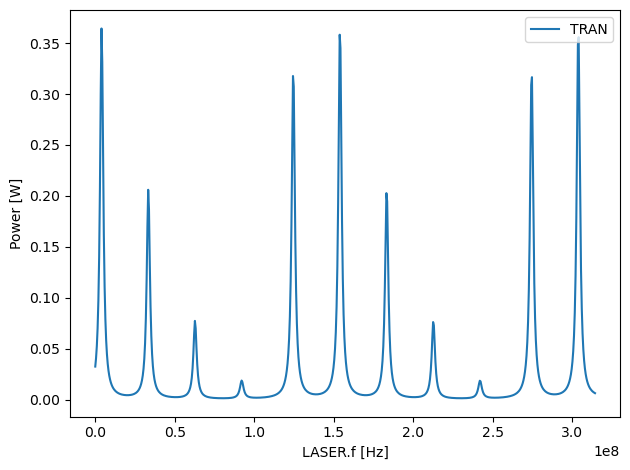

In [3]:
cav_align.m.IC.xbeta = 3e-4
cav_align.cavity_scan(ppbw_resolution = 5, plot=True);

### Compensating for the IC misalignment by turning steering mirror 2 by 150 urad:
Since SM2 happens to be at the centre of curvature of the curved cavity mirror OC, the misalignment we created by turning the plane input cavity mirror IC by $\alpha=3\times 10^{-4}$ rad can be compensated for by turning SM2 in the same direction by $\alpha/2$. When we do that, indeed only the TEM00 peaks remain visible in the cavity scan:

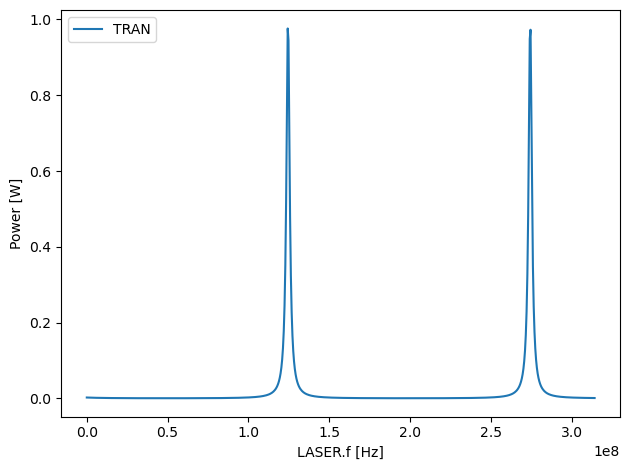

In [4]:
cav_align.sm2.xbeta = 1.5e-4
cav_align.cavity_scan(ppbw_resolution = 5, plot=True);

### Convergence testing
Including a sufficient number of TEM modes is crucial for the simulation to generate realistic cavity scans. There should be enough modes to adequately describe the shifted and misaligned beams in a fixed TEM mode basis. The convergence breaks down quickly when the misalignment angles are increased.

The `.get_convergence_curves()` method misaligns a selected optical component in the model to aid with selecting the right amount of TEM modes. Note that the Finesse parameter `maxtem` selects the highest _order_ of TEM modes to be included, not the total number of modes (i.e. `maxtem=19` will include 210 modes in total). Then the selected detectors are plotted, e.g. in our example the first plot is the sum of reflected and transmitted power by the cavity. When this value is not close to 1, this means that the power is lost into unaccounted modes. The plots show that the required amount of modes grows quickly with increasing angles. Note, however, that the signal in transmission near the resonance requires less modes to converge, since the calculation is done in the cavity basis and the cavity is assumed to belocked to the TEM00 mode, thus filtering the others.

maxtem=1 calculation finished
maxtem=3 calculation finished
maxtem=7 calculation finished
maxtem=11 calculation finished
maxtem=15 calculation finished
maxtem=19 calculation finished


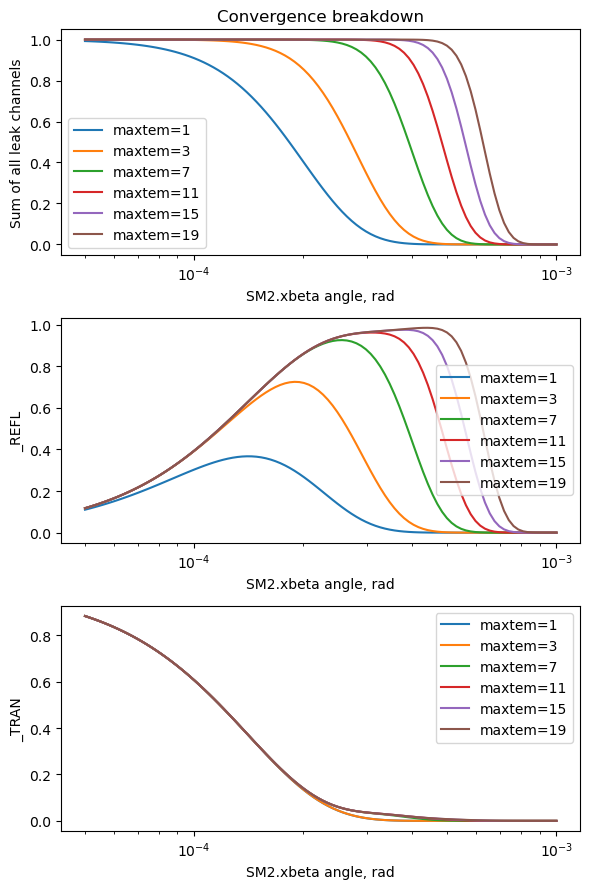

In [5]:
cav_align.m.IC.xbeta = 0
cav_align.sm2.xbeta = 0

cav_align.get_convergence_curves(axis = cav_align.sm2.xbeta,
                                 x = np.geomspace(5e-5,1e-3,100),
                                 maxtem_list = [1, 3, 7, 11, 15, 19],
                                 cavity_leak_channels = [cav_align.m.IC.p1.o, cav_align.m.OC.p2.o],
                                 leak_channel_names = ['_REFL', '_TRAN'],
                                 lock_to_mode=[0,0],
                                 plot = 'all',
                                 plot_logx = True
                                );

### Motors
The model can simulate the effect of piezoelectric stick-slip motors (e.g. the Picomotors) attached to the steering mirrors' pitch and yaw axes. Note that these motors typically have different calibration coefficients (in units of rad/count) for the positive and negative directions.

In [6]:
# attaching identical motors to all alignment degrees of freedom
cav_align.init_all_steering_motors(pos_coef=1.2e-6, neg_coef=0.9e-6, uncertainty=0.1)

Moving a motor forward and back by the same number of counts will not restore the corresponding alignment angle:

In [7]:
print(cav_align.dof_info(cav_align.sm2.xbeta))
print("Moving SM2.xbeta motor by +100 counts")
cav_align.move_steering_motor(cav_align.sm2.xbeta, 100)
print(cav_align.dof_info(cav_align.sm2.xbeta))
print("Moving SM2.xbeta motor by -100 counts")
cav_align.move_steering_motor(cav_align.sm2.xbeta, -100)
print(cav_align.dof_info(cav_align.sm2.xbeta))

SM2.xbeta = 0.0 radians, motor pos = 0
Moving SM2.xbeta motor by +100 counts
SM2.xbeta = 0.00013624512472840816 radians, motor pos = 100
Moving SM2.xbeta motor by -100 counts
SM2.xbeta = 5.347689314500548e-05 radians, motor pos = 0


## 2. Prepare the factory functions for simulation and preprocessing of cavity scans

We need to define the functions that would return the new copies of the optical layout model and of the preprocessing algorithm (it will be used by the trainer). This example project is supplied with the file `my_factories.py` which contains these functions:

```python
def cav_sim_factory():
    maxtem = 3
    mis_angle_min=-2e-4
    mis_angle_max=2e-4

    cav_sim = CavityAlignment.two_mirror_cavity(
        Lcav = 1.0,          # Cavity length IC<-->OC
        Rc = (np.inf, 3.0),  # RoCs of IC and OC
        Refl = (0.95, 0.95), # Reflection off IC and OC
        Loss = (0.0, 0.0),   # Internal loss in IC and OC
        StSp = (2.0, 1.0)    # Distances SM1<-->SM2 and SM2<-->IC
    )
    cav_sim.set_maxtem(maxtem)
    
    cav_sim.add_misalignment_axes([
        cav_sim.m.IC.xbeta,
        cav_sim.m.IC.ybeta,
        cav_sim.m.OC.xbeta,
        cav_sim.m.OC.ybeta
    ], [mis_angle_min]*4, [mis_angle_max]*4)
    
    cav_sim.init_all_steering_motors(pos_coef=1.2e-6, neg_coef=1.0e-6, uncertainty=0, low_limit=-1000, high_limit=1000)
    return cav_sim

def scan_processor_factory():
    signal_ref = None

    if signal_ref is None:
        signal_ref = cav_sim_factory().signal_ref
    return CavityScanPreProcess(signal_reference_level = signal_ref)
```

Alternatively, we could define this functions here in the notebook and dump them to a file using `pickle`:
```python
import cloudpickle

with open("my_factories.pkl", "wb") as f:
    cloudpickle.dump((cav_sim_factory, scan_processor_factory), f)
```

The stored factory methods can be loaded with `calmly.load_factories()`:

In [8]:
cav_sim_factory, scan_processor_factory = calmly.load_factories("my_factories.py")

The actual environment used to interact with the ML agents is based on `gymnasium` API ([see here](https://gymnasium.farama.org/index.html)). Once the factory functions are available, a factory function to generate the `gymnasium` environment can be obtained using `calmly.get_env_factory()`:

In [9]:
# Creating a factory function for the gymnasium environment
create_env = calmly.get_env_factory(
    cav_sim_factory=cav_sim_factory,
    scan_processor_factory=scan_processor_factory,
    monitor=False,
    training=False,
    mis_angle_min=-2.0e-4,
    mis_angle_max=2.0e-4,
    seed=0
)

Factory functions are widely used in machine learning packages such as `stable-baselines3` to provide data for the model training based on reinforcement learning. They can be used to produce [vectorised environments](https://stable-baselines3.readthedocs.io/en/master/guide/vec_envs.html) for parallel computing in `stable-baselines3`, e.g. using `SubprocVecEnv`, which is used by `calmly` to speed up the learning.

In the code block below, we use an environment created with `create_env()` in an attempt to align the originally misaligned cavity using a simple heuristic protocol `calmly.policies.iterative_policy()` which is included in `calmly`. This protocol mimics the standard lab approach to the cavity alignment: improving it with each available DoF consecutively and then repeating this procedure iteratively until the desired alignment precision is achieved. This protocol usually works quite well for small initial misalignments.

In [10]:
test_env = create_env()
out = calmly.simulate_episode_with_trained_model(
    calmly.policies.iterative_policy,
    test_env,
    Nsteps_to_print_after=20
)

step: 20 	rew: 12.83880120215835 	dom: 0.7683043729016023 	ddom: 0.008351512643112624 	Npeaks: 1
step: 40 	rew: 6.014035461709104 	dom: 0.8200080270997326 	ddom: 6.357006199408932e-05 	Npeaks: 1
Total Episode Reward: 803.8159751170291
Finished as Terminated after 57 steps
Final dominance of the main peak: 0.8169415176106778


The code below will output the cavity scans for initial and final alignment plus additional metrics for visual evaluation of the performance: total reward and its important components on every step, "dominance" (relative peak height by default) of the main peak and of other peaks, "$\delta$-dominance" (change in dominance after the last step), and the number of the action taken, according to the following map:
```python
class Actions_1(Enum):
    DECREASE_SM1_YAW = 0
    INCREASE_SM1_YAW = 1
    DECREASE_SM1_PITCH = 2
    INCREASE_SM1_PITCH = 3
    DECREASE_SM2_YAW = 4
    INCREASE_SM2_YAW = 5
    DECREASE_SM2_PITCH = 6
    INCREASE_SM2_PITCH = 7
```
(class `Actions_1` is available from `calmly.env` for convenience).

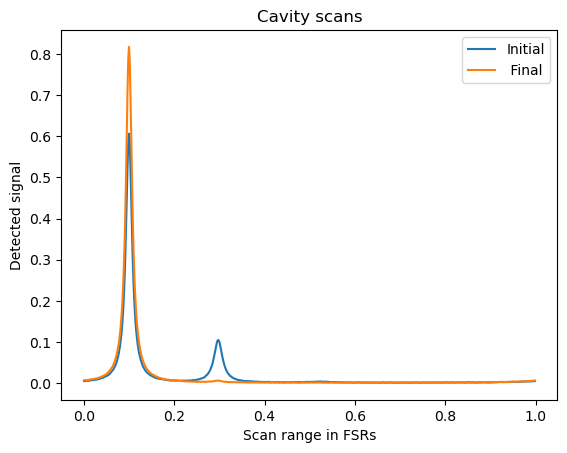

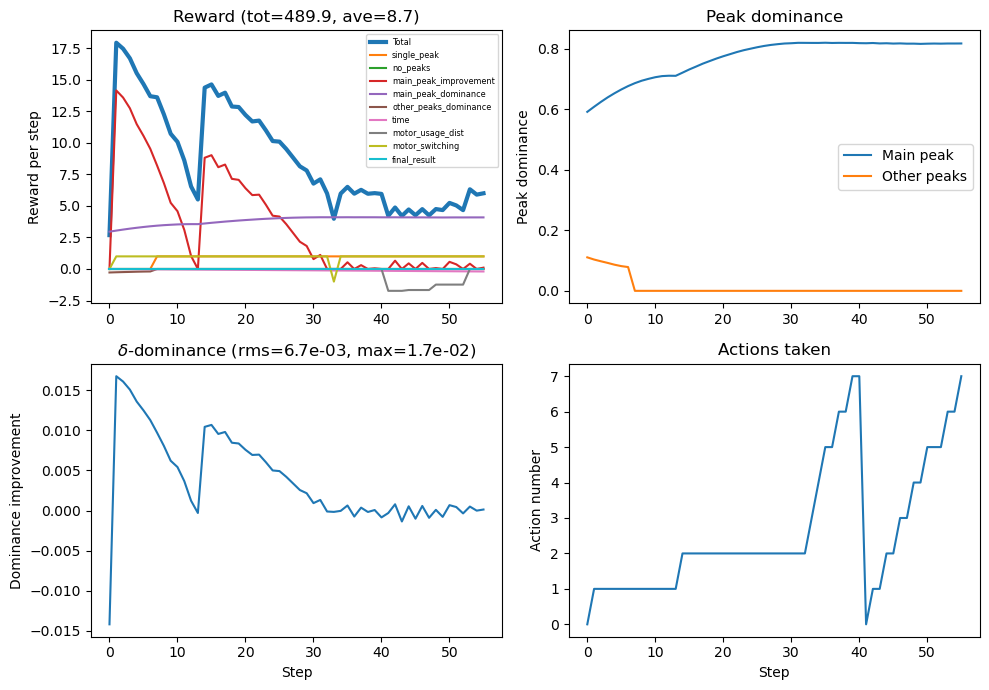

In [11]:
out.plot_cavity_scans();
out.plot_metrics(step_highlim=-1);

### Manual alignment
It is possible to use the gym environment factory to align the simulated misaligned cavity manually. In order to do this, first we need to initialise the manual alignment in the following way:

In [ ]:
test_env = create_env()
diag = calmly.manual_episode_init(test_env)

Once initialised, the cavity can be aligned by the user step-by-step by calling `calmly.manual_episode_step()` at each alignment step:

In [ ]:
calmly.manual_episode_step(test_env, diag, action=None)

The parameter `action` should be an integer representing the action number or `None` to just print out the current alignment information. This information is stored in `diag` and can be visualised (e.g. once the alignment process is complete) using `diag.plot_cavity_scans()` and `diag.plot_metrics()` as above.

## 3. Use a simple heuristic policy to create a training dataset
We are going to use `iterative_policy()` which we already used above to record a small dataset of alignment 'episodes' to be used in imitation learning at the next step.

### Configuration file for `calmly` (`calmly_config.yaml`)
The actions performed on steps 3-5 are mostly configured via the `calmly` configuration file, which is called `calmly_config.yaml` by default (this can be overriden by passing the argument `config=` to the methods from `calmly.actions`). A copy of `calmly_config.yaml` is included in this project and can be used as a template. It is sectioned into parts representing different actions:

```yaml
# User factory definition module and environment settings
general:
  factory_module: "my_factories.py"  # User-defined Python or pickle file containing the factory functions
  env_settings: "env_settings.yaml" # Environment settings (can also be a nested dictionary)
  norm_observations: true # Use VecNormalize to normalize the observations
  norm_rewards: true # Use VecNormalize to normalize the rewards

# Heuristic dataset generation
dataset:
  enabled: true
  quiet: false
  n_episodes: 200
  path: "data/heuristic_dataset.pkl"
  n_peaks: 5
  maxtem: 5
  mis_angle_min: -2.0e-4
  mis_angle_max: 2.0e-4
  policy: "default" # or a pickle path
  seed: 42

# Behavioral Cloning
bc:
  enabled: true
  quiet: false
  policy_save_path: "models/bc_policy.pt"
  torch_num_threads: 10
  n_envs: 4
  device: "mps"
  net_arch: [64, 64]
  learning_rate: 1e-4
  n_epochs: 10
  seed: 142

# PPO Fine-Tuning
ppo:
  enabled: true
  quiet: false
  continue_training: false
  skip_bc: false
  device: "cpu"
  n_envs: 10
  torch_num_threads: 1
  learning_rate: 3e-4
  total_timesteps: 400000
  ent_coef: 0.02
  exploration_settings:
    enabled: true
  tensorboard_log_dir: "logs/ppo"
  tensorboard_log_name: "PPO_MultiEnv"
  save_path: "models/ppo_policy"
  load_path: "models/ppo_policy"
  save_freq: 50000
  n_peaks: 5
  maxtem: 5
  mis_angle_min: -4.0e-4
  mis_angle_max: 4.0e-4
  seed: 242

# Evaluation
evaluation:
  enabled: true
  quiet: false
  n_episodes: 20
  agent_path: "iterative_policy"
  n_peaks: 5
  maxtem: 5
  mis_angle_min: -4.0e-4
  mis_angle_max: 4.0e-4
  seed: 342
  save_path: "evaluation/evaluation_results.yaml"
  message: "My evaluation"

```

With this file in place, we can simply record the training dataset and save it at `data/heuristic_dataset.pkl` by calling `calmly.actions.generate_dataset()` (or `calmly-generate_dataset` in the terminal).

Note: the cell below will produce a dataset with 200 episodes. This might take some time to compute. A pre-recorded copy is already available at `data/heuristic_dataset.pkl`.

In [ ]:
# Takes approx. 33 minutes on a 2023 Apple M3 MBP
calmly.actions.generate_dataset()

## 4. Pretrain the agent using behavioural cloning with the recorded dataset.
This step takes advantage of the dataset we recorded previously to show the agent some examples of the "winning" alignment strategy, which otherwise it might take too long to discover. With the parameters specified in `calmly_config.yaml`, we can run the following cell to train an agent with behavioral cloning (BC) for 10 epochs and store the result to `models/bc_policy.pt` in the form of a PPO-compatible policy (to be loaded in the PPO model at the next step). Again, a pre-recorded copy is already included in the distribution.

In [ ]:
# Takes approx. 1 minute on a 2023 Apple M3 MBP
calmly.actions.train_bc_model()

## 5. Train the PPO agent.
PPO stands for "[proximal policy optimisation](https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html)", a powerful policy gradient algorithm for reinforcement learning. In this example, we are going to use it for a wider range of initial misalignment angles to extend the range of policy trained by the simple heuristic algorithm. The following will store the resulting PPO model in `models/ppo_policy.zip` (a pre-recorded copy is included).

In [ ]:
# Takes approx. 27 minutes on a 2023 Apple M3 MBP
calmly.actions.train_ppo_model()

## 6. Evaluate the agent performance
We already described above a method, `calmly.simulate_episode_with_trained_model()`, which allows for running a single 'episode' of aligning a misaligned cavity using a trained model or a policy algorithm. A more general approach to the evaluation is to use `calmly.actions.evaluate_model()` (or its command-line script, `calmly-evaluate`). It collects performance data for several episodes using settings from the `evaluation` section of the project config file (`calmly_config.yaml` by default) and stores the results in another YAML file.